In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\DELL\anaconda3\1\envs\py11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import seaborn as sns

In [4]:
df_da_us=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()

df_da_us=df_da_us.dropna(subset=['salary_year_avg'])

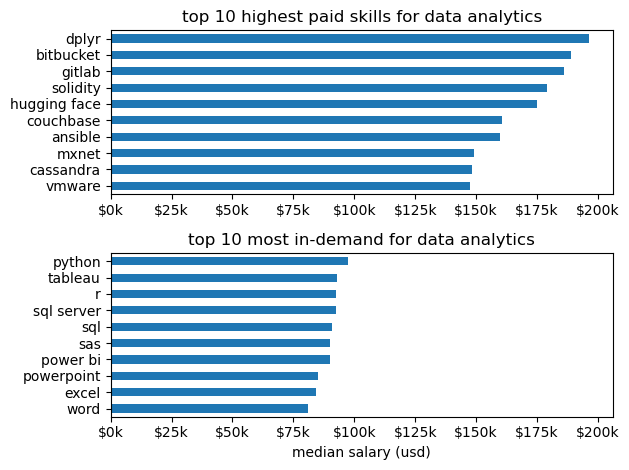

In [7]:
df_da_us=df_da_us.explode('job_skills')

df_da_top_pay= df_da_us.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='median', ascending=False)
df_da_top_pay= df_da_top_pay.head(10)

df_da_skills=df_da_us.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count', ascending=False)
df_da_skills=df_da_skills.head(10).sort_values(by='median', ascending=False)

fig, ax=plt.subplots(2,1)

#top 10 highest paid skills for data analysts
df_da_top_pay[::-1].plot(kind='barh' , y='median', ax=ax[0], legend =False)
ax[0].set_title('top 10 highest paid skills for data analytics')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${int(x/1000)}k'))

#top 10 most in demand skills for data analysts
df_da_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('top 10 most in-demand for data analytics')
ax[1].set_xlabel('median salary (usd)')
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim())   # set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))

plt.tight_layout()
plt.show()

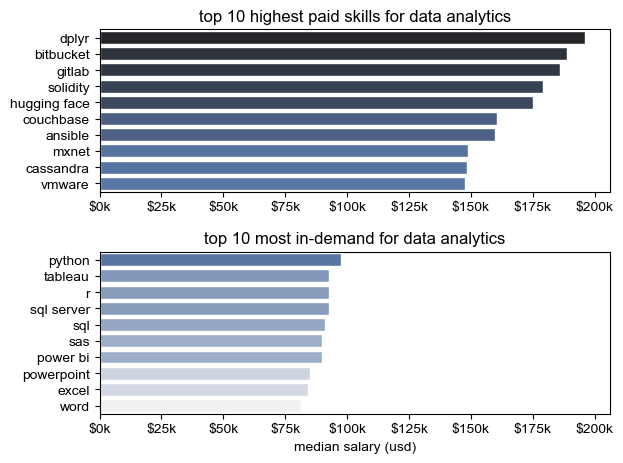

In [13]:
fig, ax=plt.subplots(2,1)

sns.set_theme(style='ticks')

#top 10 highest paid skills for data analysts

sns.barplot(data=df_da_top_pay, x='median', y=df_da_top_pay.index, ax=ax[0], hue='median', palette='dark:b_r')
#df_da_top_pay[::-1].plot(kind='barh' , y='median', ax=ax[0], legend =False)
ax[0].set_title('top 10 highest paid skills for data analytics')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${int(x/1000)}k'))
ax[0].legend().remove()

#top 10 most in demand skills for data analysts

sns.barplot(data=df_da_skills, x='median', y=df_da_skills.index, ax=ax[1], hue='median', palette='light:b')

#df_da_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('top 10 most in-demand for data analytics')
ax[1].set_xlabel('median salary (usd)')
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim())   # set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))
ax[1].legend().remove()
plt.tight_layout()
plt.show()

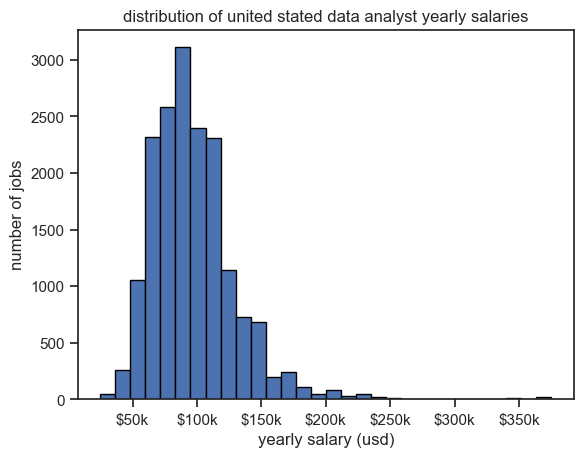

In [14]:
df_da_us['salary_year_avg'].plot(kind='hist', bins=30, edgecolor='black')

plt.title('distribution of united stated data analyst yearly salaries')
plt.xlabel('yearly salary (usd)')
plt.ylabel('number of jobs')
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'${int(y/1000)}k'))
plt.show()

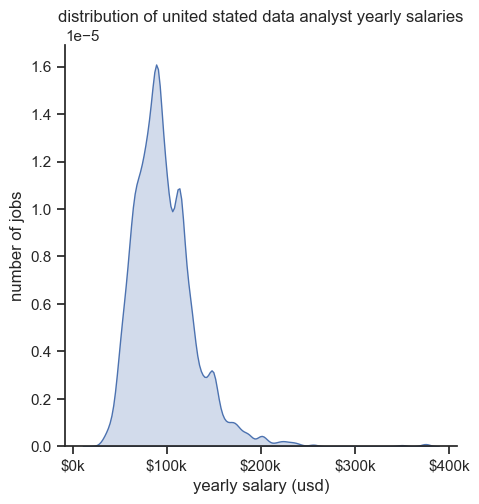

In [18]:
sns.set_theme(style='ticks')
sns.displot(data=df_da_us['salary_year_avg'], kind='kde', fill=True)
plt.title('distribution of united stated data analyst yearly salaries')
plt.xlabel('yearly salary (usd)')
plt.ylabel('number of jobs')
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'${int(y/1000)}k'))
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_39368\3226766754.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


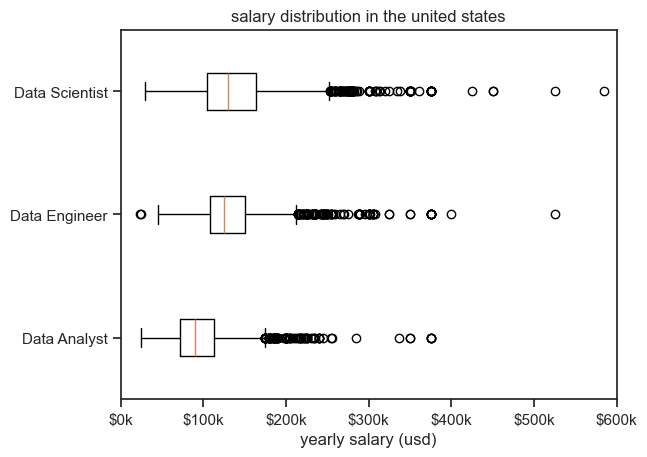

In [20]:
job_titles=['Data Analyst', 'Data Engineer', 'Data Scientist']

#filter for the job titles and country
df_us= df[(df['job_title_short'].isin(job_titles)) & (df['job_country']=='United States')].dropna(subset='salary_year_avg')

#list of salaries for each job
job_list=[df_us[df_us['job_title_short']==job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('salary distribution in the united states')
plt.xlabel('yearly salary (usd)')
plt.xlim(0, 600000)
ticks_x =plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

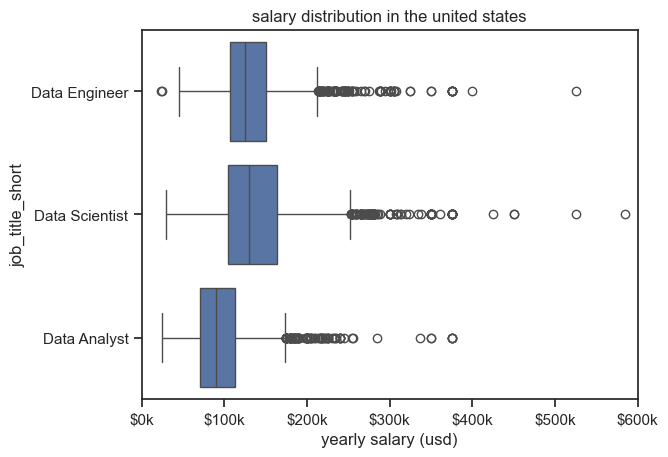

In [21]:
sns.boxplot(data=df_us, x='salary_year_avg', y='job_title_short')

plt.title('salary distribution in the united states')
plt.xlabel('yearly salary (usd)')
plt.xlim(0, 600000)
ticks_x =plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()